In [1]:
from google.colab import files
df = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  

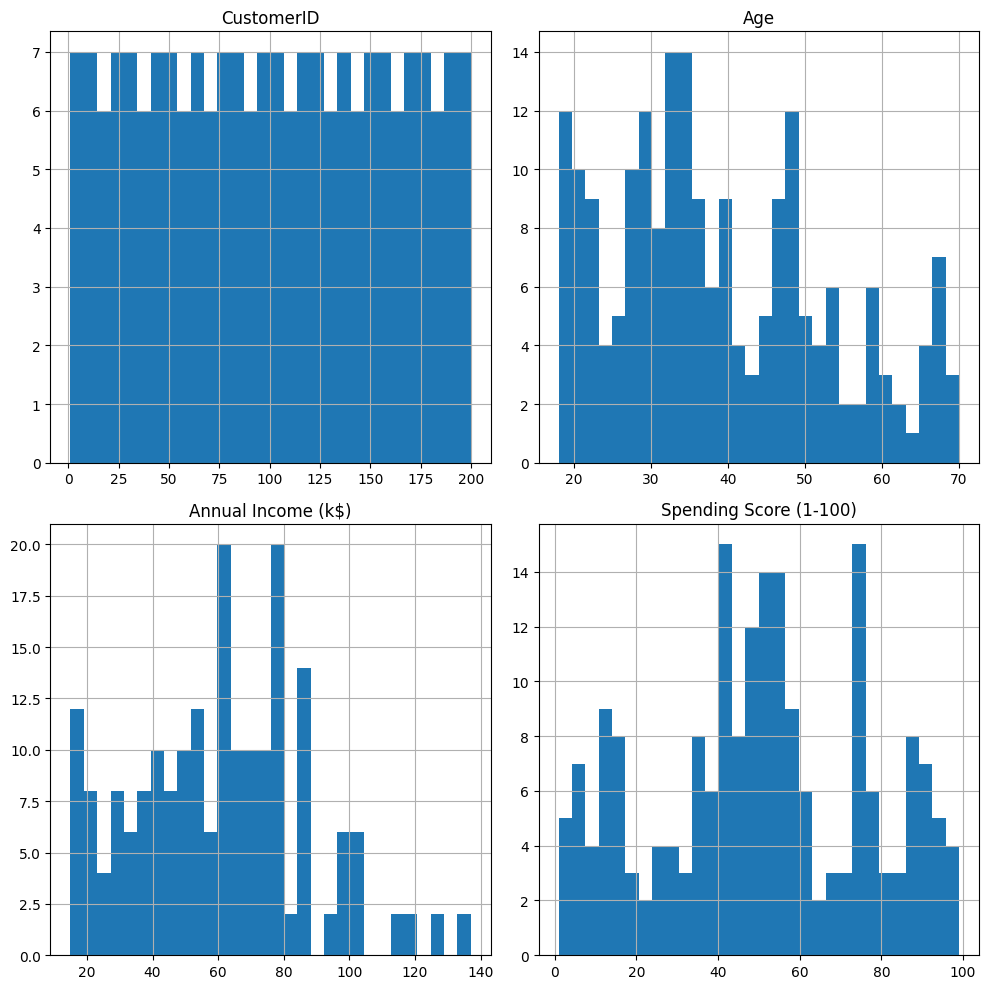

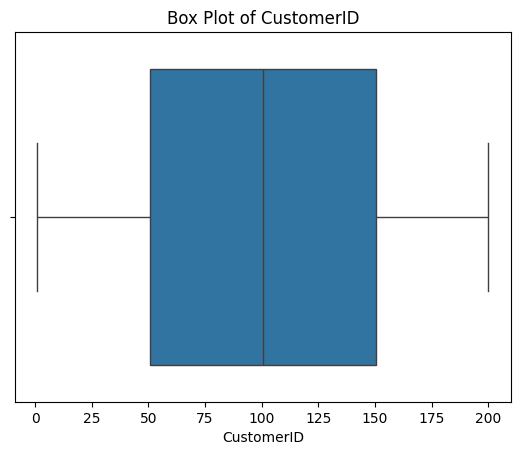

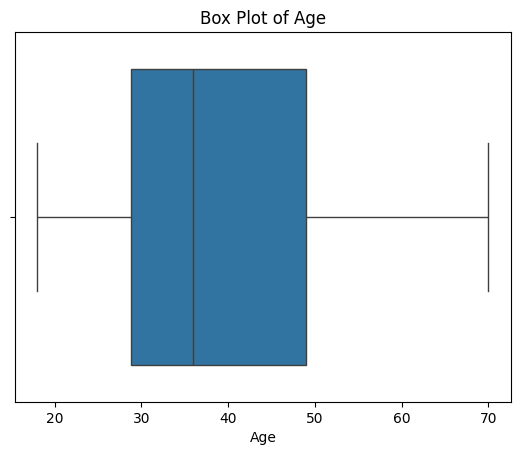

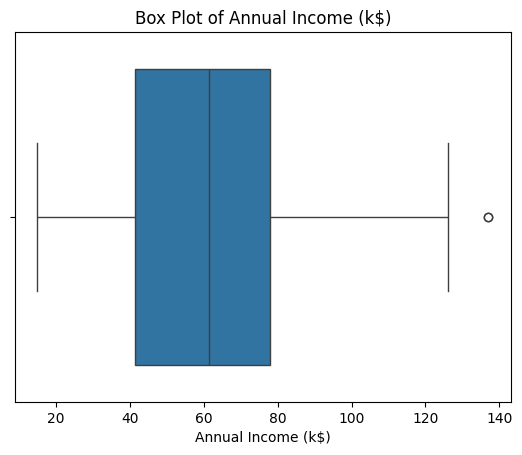

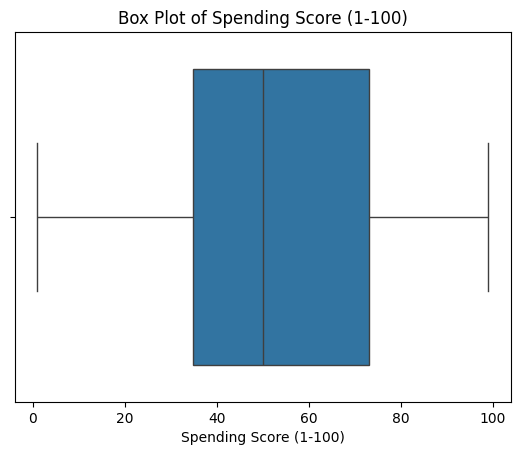

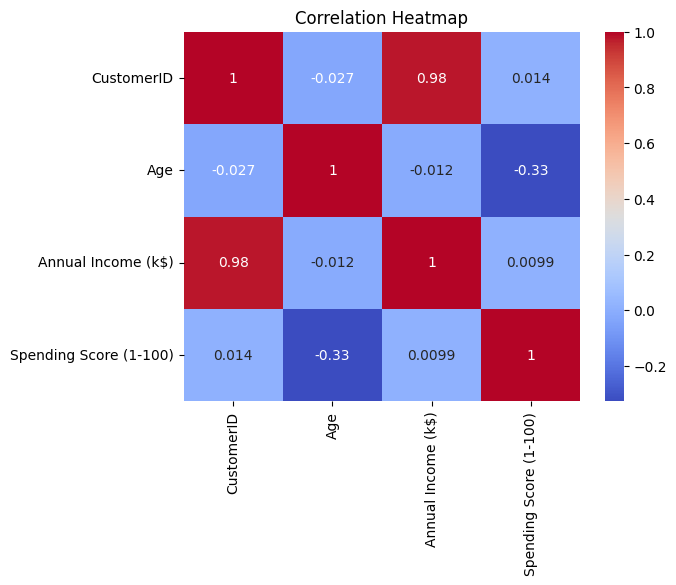

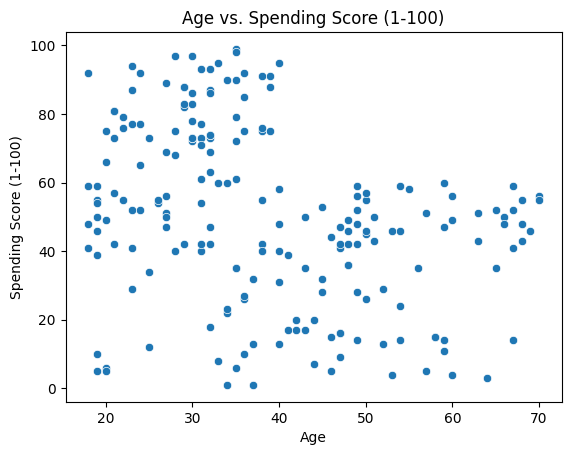

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset (assuming it's already uploaded)
df = pd.read_csv('Mall_Customers.csv')

# 1. First look at the data
print(df.head())  # First 5 rows
print(df.info())  # Data types and missing values
print(df.describe())  # Summary statistics

# 2. Check for missing values (again, just to confirm)
print(df.isnull().sum())

# 3. Visualize distributions of numerical columns
df.hist(bins=30, figsize=(10, 10))
plt.tight_layout()
plt.show()

# 4. Box plots to check for outliers
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

# 5. Correlation Heatmap to see relationships between features
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 6. Check relationships between two variables (example: Age vs. Spending Score)
sns.scatterplot(x='Age', y='Spending Score (1-100)', data=df)
plt.title('Age vs. Spending Score (1-100)')
plt.show()

In [ ]:
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')

from sklearn.cluster import KMeans

from sklearn.cluster import AgglomerativeClustering

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

kmeans = KMeans(n_clusters=5, random_state=42)

kmeans_labels = kmeans.fit_predict(X)

hc = AgglomerativeClustering(n_clusters=5)

hierarchical_labels = hc.fit_predict(X)

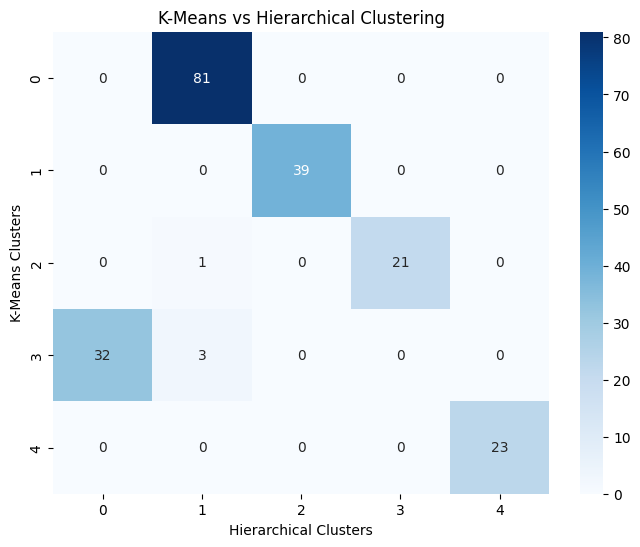

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(kmeans_labels, hierarchical_labels)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('K-Means vs Hierarchical Clustering')
plt.xlabel('Hierarchical Clusters')
plt.ylabel('K-Means Clusters')

plt.show()

In [ ]:
import pandas as pd

cluster_matrix = pd.crosstab(
    kmeans_labels,
    hierarchical_labels,
    rownames=['KMeans'],
    colnames=['Hierarchical']
)

print(cluster_matrix)

Hierarchical   0   1   2   3   4
KMeans                          
0              0  81   0   0   0
1              0   0  39   0   0
2              0   1   0  21   0
3             32   3   0   0   0
4              0   0   0   0  23


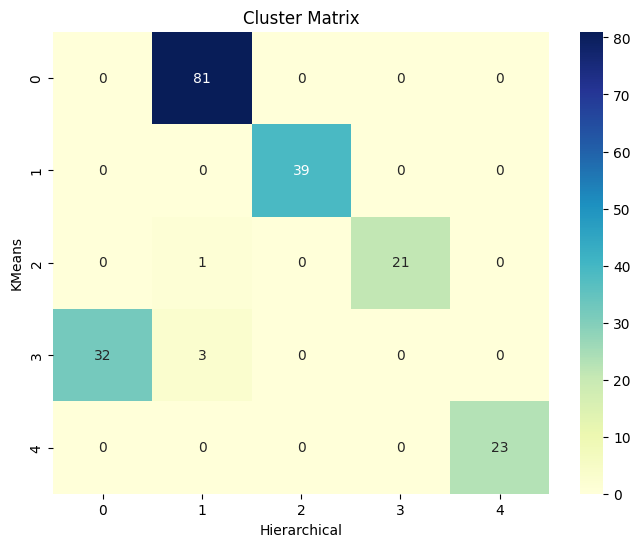

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cluster_matrix,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title('Cluster Matrix')
plt.show()

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print(X_pca[:5])

[[-46.90357403   1.0992468 ]
 [-35.92438931  41.63882626]
 [-54.56484822 -31.01468908]
 [-36.00479787  37.51650477]
 [-44.7117087    1.54165656]]


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

print(kmeans)

KMeans(n_clusters=5, random_state=42)


In [ ]:
kmeans_labels = kmeans.fit_predict(X_pca)

print(kmeans_labels[:10])

[4 2 4 2 4 2 4 2 4 2]


In [ ]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=5)

hc_labels = hc.fit_predict(X_pca)

print(hc_labels[:10])

[4 3 4 3 4 3 4 3 4 3]


In [ ]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=5,
    random_state=42
)

gmm_labels = gmm.fit_predict(X_pca)

print(gmm_labels[:10])

[4 2 4 2 4 2 4 2 4 2]


In [ ]:
from sklearn.metrics import davies_bouldin_score

print("K-Means DB Index:",
      davies_bouldin_score(X_pca, kmeans_labels))

print("Hierarchical DB Index:",
      davies_bouldin_score(X_pca, hc_labels))

print("GMM DB Index:",
      davies_bouldin_score(X_pca, gmm_labels))

K-Means DB Index: 0.5725628995597092
Hierarchical DB Index: 0.5782207452369458
GMM DB Index: 0.5764125247353642


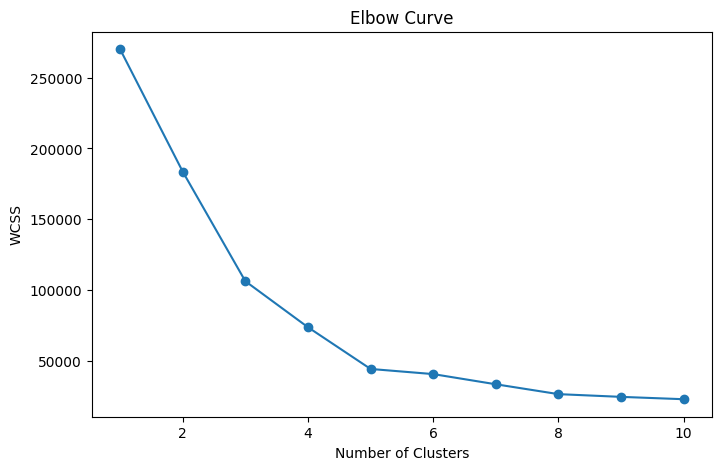

In [ ]:
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    km = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    km.fit(X_pca)

    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Curve")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [ ]:
from sklearn.cluster import KMeans

# Select the features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Train K-Means
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)

# Create Cluster column
df['Cluster'] = kmeans.fit_predict(X)

# Check that it was added
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


In [ ]:
print(df.columns.tolist())

['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']


In [ ]:
df.to_csv("final_customer_segments.csv", index=False)

In [ ]:
from google.colab import files

files.download("final_customer_segments.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>